In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from scipy import sparse

In [2]:
# Load data
train_path = "data/train.csv"
test_path = "data/test.csv"
sample_sub_path = "data/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

In [3]:
target_col = "diagnosed_diabetes"
id_col = "id"

In [4]:
# Split features and target
X = train_df.drop(columns=[target_col])
y = train_df[target_col]
X_test = test_df.copy()

In [5]:
# Detect numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols = [col for col in num_cols if col in X.columns]
cat_cols = [col for col in cat_cols if col in X.columns]

if id_col in num_cols:
    num_cols.remove(id_col)
if id_col in cat_cols:
    cat_cols.remove(id_col)

In [6]:
poly_cols = [
    "age",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "ldl_cholesterol",
    "physical_activity_minutes_per_week"
]

poly_cols = [col for col in poly_cols if col in num_cols]
remaining_num_cols = [col for col in num_cols if col not in poly_cols]

print("Polynomial feature columns:", poly_cols)
print("Remaining numeric columns:", remaining_num_cols)
print("cat_cols:", cat_cols)

Polynomial feature columns: ['age', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'ldl_cholesterol', 'physical_activity_minutes_per_week']
Remaining numeric columns: ['alcohol_consumption_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
cat_cols: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [7]:
X = X[num_cols + cat_cols]
X_test = X_test[num_cols + cat_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [8]:
poly_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

remaining_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("poly_num", poly_numeric_transformer, poly_cols),
        ("num", remaining_numeric_transformer, remaining_num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    verbose_feature_names_out=False
)

In [9]:
def get_transformed_feature_matrix(preprocessor, X, y):
    X_trans = preprocessor.fit_transform(X, y)
    feature_names = preprocessor.get_feature_names_out()

    if sparse.issparse(X_trans):
        X_trans = X_trans.toarray()

    X_trans = pd.DataFrame(X_trans, columns=feature_names, index=X.index)
    return X_trans, feature_names

In [10]:
def mrmr_select(X_trans, y, k=80):
    mi = mutual_info_classif(X_trans, y, random_state=42)
    mi_series = pd.Series(mi, index=X_trans.columns)

    corr_matrix = X_trans.corr().abs().fillna(0.0)

    selected = []
    remaining = list(X_trans.columns)

    first_feature = mi_series.idxmax()
    selected.append(first_feature)
    remaining.remove(first_feature)

    while len(selected) < min(k, len(X_trans.columns)):
        best_feature = None
        best_score = -np.inf

        for feature in remaining:
            relevance = mi_series[feature]
            redundancy = corr_matrix.loc[feature, selected].mean() if selected else 0.0
            score = relevance - redundancy

            if score > best_score:
                best_score = score
                best_feature = feature

        selected.append(best_feature)
        remaining.remove(best_feature)

    mrmr_table = pd.DataFrame({
        "feature": selected,
        "mi": [mi_series[f] for f in selected]
    })

    return selected, mrmr_table, mi_series, corr_matrix

In [11]:
def jmi_rerank(X_trans, y, candidate_features, k=30):
    mi = mutual_info_classif(X_trans[candidate_features], y, random_state=42)
    mi_series = pd.Series(mi, index=candidate_features)

    selected = []
    remaining = list(candidate_features)

    first_feature = mi_series.idxmax()
    selected.append(first_feature)
    remaining.remove(first_feature)

    while len(selected) < min(k, len(candidate_features)):
        best_feature = None
        best_score = -np.inf

        for feature in remaining:
            relevance = mi_series[feature]

            complementarity = 0.0
            for s in selected:
                pair_feature = X_trans[feature] * X_trans[s]
                pair_feature = pair_feature.values.reshape(-1, 1)
                pair_mi = mutual_info_classif(pair_feature, y, random_state=42)[0]
                complementarity += pair_mi

            score = relevance + complementarity

            if score > best_score:
                best_score = score
                best_feature = feature

        selected.append(best_feature)
        remaining.remove(best_feature)

    jmi_table = pd.DataFrame({
        "feature": selected,
        "mi_like_rank": range(1, len(selected) + 1)
    })

    return selected, jmi_table

In [12]:
X_trans, feature_names = get_transformed_feature_matrix(preprocessor, X, y)

print("Transformed shape:", X_trans.shape)
print("First 10 features:", list(feature_names[:10]))

Transformed shape: (700000, 63)
First 10 features: ['age', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'ldl_cholesterol', 'physical_activity_minutes_per_week', 'age^2', 'age bmi', 'age waist_to_hip_ratio', 'age systolic_bp']


In [13]:
mrmr_features, mrmr_table, mi_series_full, corr_matrix = mrmr_select(
    X_trans,
    y,
    k=80
)

print(mrmr_table.head(20))
print("Number of mRMR-selected features:", len(mrmr_features))

                                 feature        mi
0             employment_status_Employed  0.079936
1                   smoking_status_Never  0.079843
2                        ethnicity_White  0.068093
3                          gender_Female  0.064933
4             education_level_Highschool  0.060457
5                    income_level_Middle  0.043731
6   physical_activity_minutes_per_week^2  0.035074
7                family_history_diabetes  0.032846
8           alcohol_consumption_per_week  0.017284
9                                    age  0.016549
10                            diet_score  0.003501
11                   sleep_hours_per_day  0.001677
12             screen_time_hours_per_day  0.001233
13                          gender_Other  0.000421
14                  hypertension_history  0.009262
15                       hdl_cholesterol  0.004707
16                cardiovascular_history  0.000650
17                           gender_Male  0.057250
18                     income_l

In [15]:
jmi_features, jmi_table = jmi_rerank(
    X_trans,
    y,
    candidate_features=mrmr_features,
    k=30
)

print(jmi_table.head(20))
print("Final JMI-like selected features:", jmi_features[:20])

KeyboardInterrupt: 

In [17]:
X_selected = X_trans[mrmr_features].copy()

lgbm_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgbm_model,
    X_selected,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Fold AUC scores:", cv_scores)
print("Mean CV AUC:", cv_scores.mean())
print("Std CV AUC:", cv_scores.std())

2574.32s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
       ^^^^^^^^^^^^^^^^^^^^
TypeError: a bytes-like object is required, not 'str'
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATI

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 349046, number of negative: 210954
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 349046, number of negative: 210954
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 349045, number of negative: 210955
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 349046, number of negative: 210954
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 349045, number of negative: 210955
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.095932 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6278
[LightGBM] [Info] Number of data points

In [19]:
X_test_trans = preprocessor.transform(X_test)

if sparse.issparse(X_test_trans):
    X_test_trans = X_test_trans.toarray()

X_test_trans = pd.DataFrame(
    X_test_trans,
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

In [23]:
X_test_selected = X_test_trans[mrmr_features].copy()

lgbm_model.fit(X_selected, y)
test_pred_proba = lgbm_model.predict_proba(X_test_selected)[:, 1]

submission = sample_sub.copy()
submission.iloc[:, 1] = test_pred_proba
submission.to_csv("submissions/lightgbm_poly_mrmr_jmi.csv", index=False)

print("Saved: submissions/lightgbm_poly_mrmr_jmi.csv")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 436307, number of negative: 263693
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6276
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.623296 -> initscore=0.503561
[LightGBM] [Info] Start training from score 0.503561


/var/folders/m_/gq3fgb6x2rs_xpbs_2llxbvc0000gn/T/ipykernel_22117/1642250127.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.51195366 0.65019242 0.76386114 ... 0.513082   0.62194646 0.61522917]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.iloc[:, 1] = test_pred_proba


Saved: submissions/lightgbm_poly_mrmr_jmi.csv


                                              feature  importance
6                physical_activity_minutes_per_week^2        2518
26                                      triglycerides         911
22                 physical_activity_minutes_per_week         460
32                                  cholesterol_total         319
33                                         heart_rate         287
59                                            age bmi         280
9                                                 age         269
15                                    hdl_cholesterol         256
10                                         diet_score         247
41                                      systolic_bp^2         226
58                                age ldl_cholesterol         195
45                                  ldl_cholesterol^2         191
48                                              bmi^2         189
38                               waist_to_hip_ratio^2         178
12        

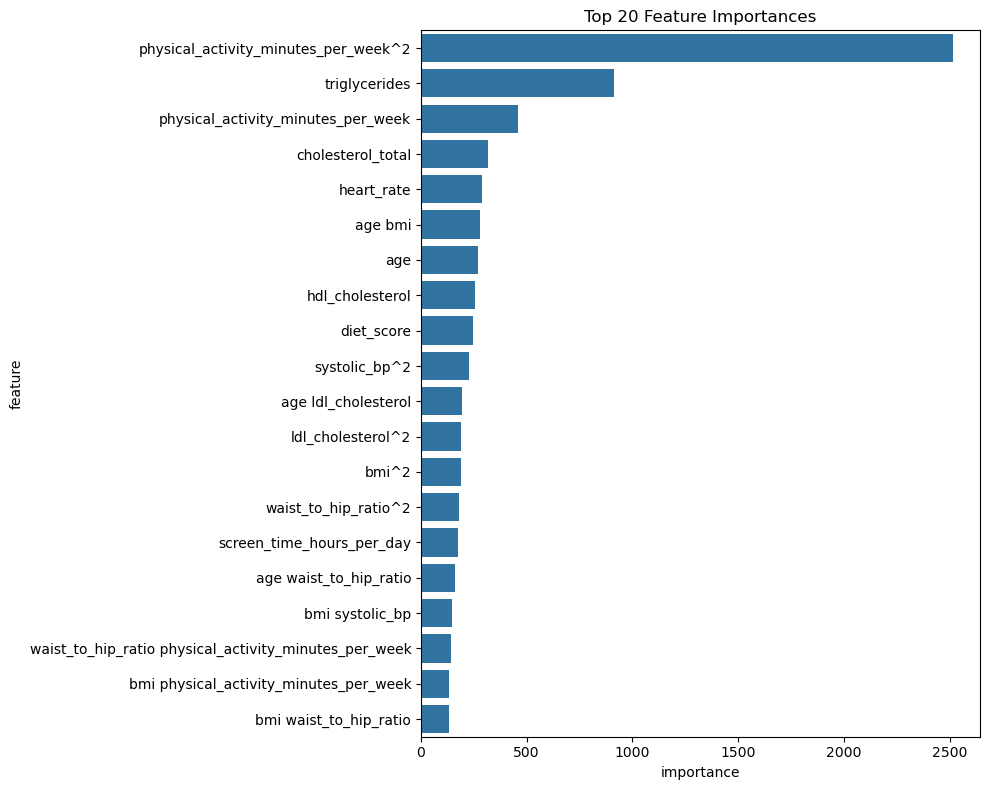

In [24]:
importance_df = pd.DataFrame({
    "feature": mrmr_features,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(30))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()